In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
df_ab_test = pd.read_csv('/content/drive/MyDrive/Data Analysis Showcase/3. Appendix Stimulated Projects/AB testing/AB testing_new check out flow.csv')
display(df_ab_test.head())

,user_id,group,age,country,sessions,avg_session_time_min,converted,revenue,churned
0,1,control,57,VN,1,7.7,0,0.0,1
1,2,treatment,24,TH,3,8.4,0,0.0,0
2,3,control,49,VN,5,1.8,0,0.0,0
3,4,control,36,VN,6,3.4,0,0.0,1
4,5,control,23,VN,8,10.3,0,0.0,0


### **1. Randomization Validating**
The main purpose is to validate users equally allocated to control and treatment experiences in terms of number of users, characteristics, and behaviours that isolately affect on purchases no matter what of flow users experience. This preliminary play a pivotal role as it helps recognize favor biases.<br>
The tasks is to compare the allocation in two groups and distributions of charasteristics to check whether one of those groups is favourable in randomization process.

In [ ]:
# number of users by groups
df_ab_test.groupby('group').user_id.count()

,user_id
group,
control,5013
treatment,4987


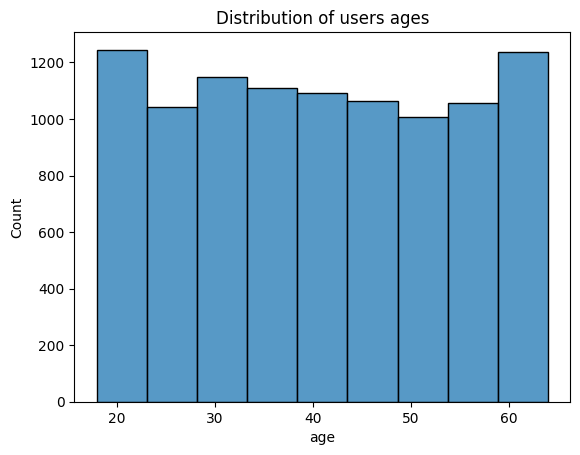

In [ ]:
# distribution of users' ages
sns.histplot(data=df_ab_test, x='age', binwidth=5)
plt.title('Distribution of users ages')
plt.show()

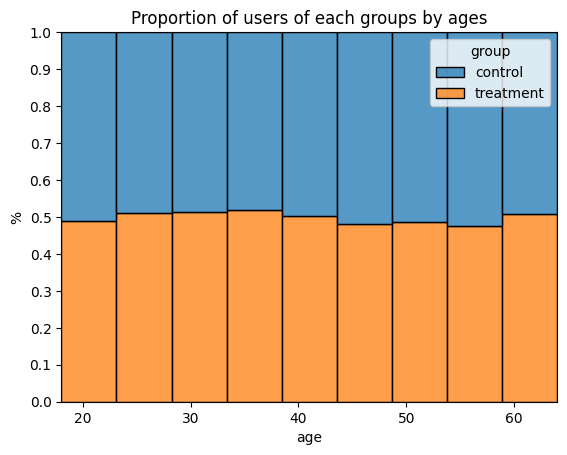

In [ ]:
# proportion of users in 2 groups by ages
sns.histplot(data=df_ab_test, x='age', binwidth=5, hue='group', multiple='fill')
plt.yticks(np.arange(0,1.1,0.1))
plt.ylabel('%')
plt.title('Proportion of users of each groups by ages')
plt.show()

> The histogram is approximately uniform, which can show the even presence of users regardless of ages. Otherwise, users are equally allocated to the treatment and control flow.

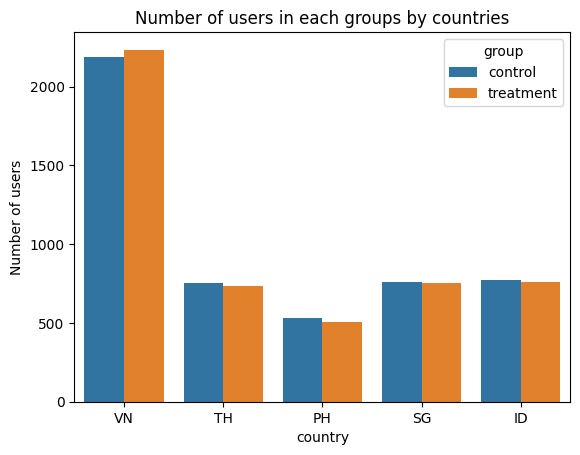

In [ ]:
# number of users in 2 groups by countries
sns.countplot(data=df_ab_test, x='country', hue='group')
plt.title('Number of users in each groups by countries')
plt.ylabel('Number of users')
plt.show()

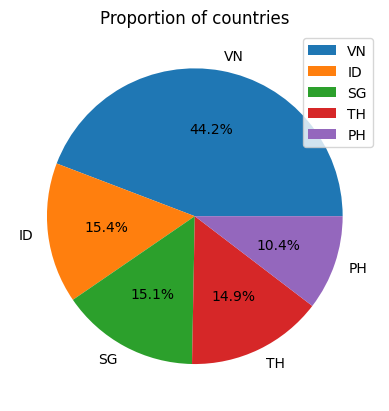

In [ ]:
# proportion of countries in total

plt.pie(df_ab_test.country.value_counts(), labels= df_ab_test.country.value_counts().index, autopct='%1.1f%%')
plt.legend()
plt.title('Proportion of countries')
plt.show()

> Vietnamese users has a prevalent presence in the data, while 4 other ASEAN countries including Indonesia, Singapore, Thailand, and Philippines share the equivalant proportion.

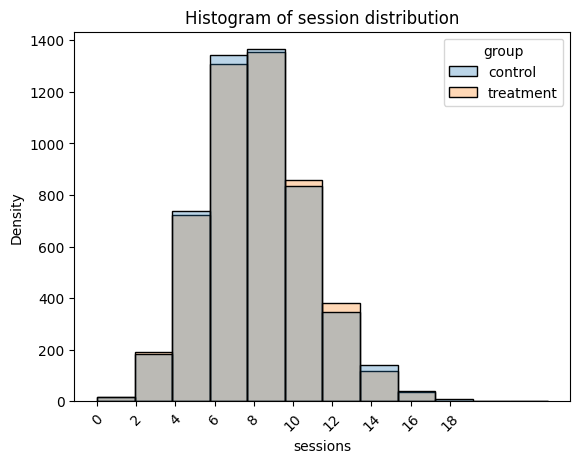

In [ ]:
# distribution of sessions

sns.histplot(data=df_ab_test, x='sessions', binwidth=2, hue='group', alpha=0.3)
plt.xticks(np.arange(0,20,2), rotation=45)
plt.ylabel('Density')
plt.title('Histogram of session distribution')
plt.show()

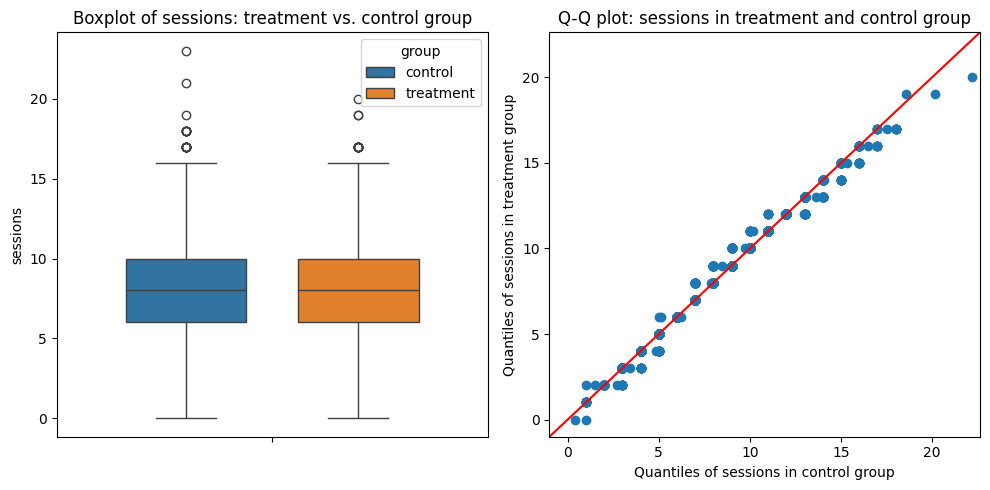

In [ ]:
# boxplot of sessions between control and treatment group

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

sns.boxplot(data=df_ab_test, y='sessions', hue='group', gap=0.3, ax=ax[0])
ax[0].set_title('Boxplot of sessions: treatment vs. control group')

sm.qqplot_2samples(data1=df_ab_test[df_ab_test['group'] == 'control']['sessions'],
                   data2=df_ab_test[df_ab_test['group'] == 'treatment']['sessions'],
                   xlabel='Quantiles of sessions in control group',
                   ylabel='Quantiles of sessions in treatment group',
                   line='45',
                   ax=ax[1])
ax[1].set_title('Q-Q plot: sessions in treatment and control group')

plt.tight_layout()
plt.show()

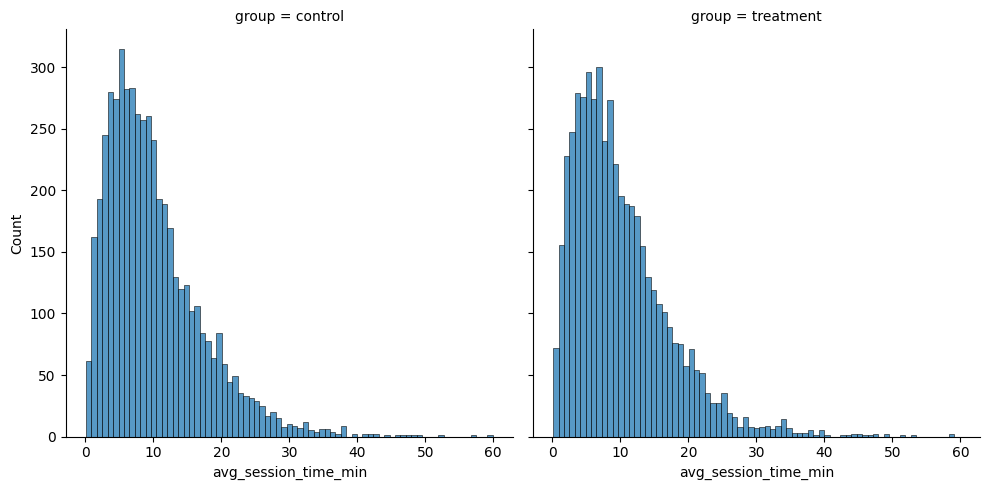

In [ ]:
# distribution of average time per session(min) (avg_session_time_min)

sns.displot(data=df_ab_test, x='avg_session_time_min', col='group')
plt.show()

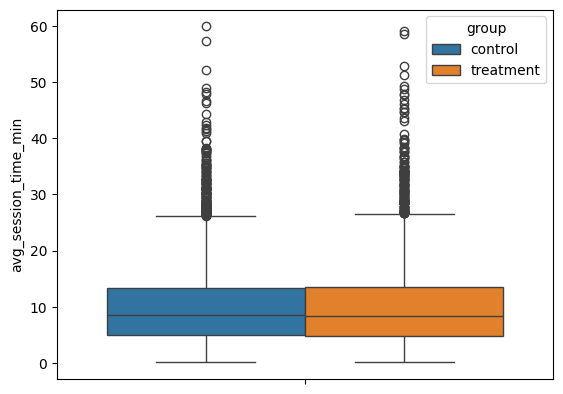

In [ ]:
# boxplot of average time per session(min) (avg_session_time_min)

sns.boxplot(data=df_ab_test, y='avg_session_time_min', hue='group')
plt.show()

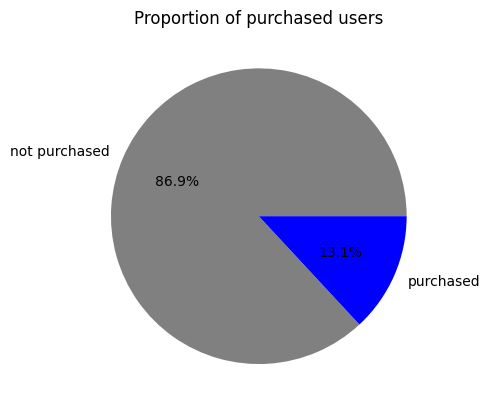

In [ ]:
# proportion of purchased users

df_ab_test['purchased_label'] = df_ab_test['converted'].map({0: 'not purchased', 1: 'purchased'})

plt.pie(df_ab_test.purchased_label.value_counts(),
        labels= df_ab_test.purchased_label.value_counts().index,
        autopct='%1.1f%%',
        colors=['grey', 'blue'])
plt.title('Proportion of purchased users')
plt.show()

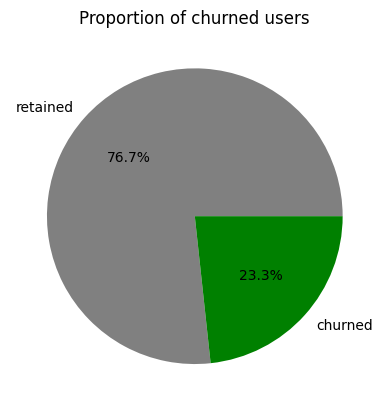

In [ ]:
# proportion of churned users

df_ab_test['churned_label'] = df_ab_test['churned'].map({0: 'retained', 1: 'churned'})

plt.pie(df_ab_test.churned_label.value_counts(),
        labels= df_ab_test.churned_label.value_counts().index,
        autopct='%1.1f%%',
        colors=['grey', 'green'])
plt.title('Proportion of churned users')
plt.show()

#### **Findings:**
After reviewing indenpedent variables in the dataset, critical information has revealed:<br>
1. The randomization in this experiment is eligible as we can see the equivalent allocation of users in terms of ages, countries, and experience quality (number of sessions and duration per session) in treatment group and control group.<br>
2. Vietnamese users are dominantly presented (40%) than other ASEAN countries, which can be either a bias in randomization or a reflect of the population. **In reality, this disproportion needs checking and verifying carefully before executing next steps.**
3. Most users has logged in 6-8 sessions and spent around 10 minutes per sessions in the last 4 weeks of the experiment, refering to tech-savvy and high-quality. **This finding raises an question about the representative of this sample and also needs checking if it truely reflect all users.**
4. **Only 13.1% of all users purchased but disproportionately 23.3% churned.** This noticeable discrepancy reveals an unexpected disappointment of users that needs further working on.

### **2. Geography allocation check**
I would like to explore on characteristics of users in different nations: do they differ in `number of sessions taken`, `average time per session`, `churn rate`, and `conversion rate`?

In [ ]:
# mean and median of number of sessions taken and average time per session

df_ab_test.groupby('country')[['sessions', 'avg_session_time_min']].agg(['mean','median'])

sessions        avg_session_time_min       
             mean median                 mean median
country                                             
ID       8.018868    8.0             9.934027   8.40
PH       7.998073    8.0             9.859056   8.35
SG       7.966292    8.0             9.926966   8.40
TH       8.014745    8.0             9.993432   8.50
VN       7.979864    8.0            10.178575   8.50

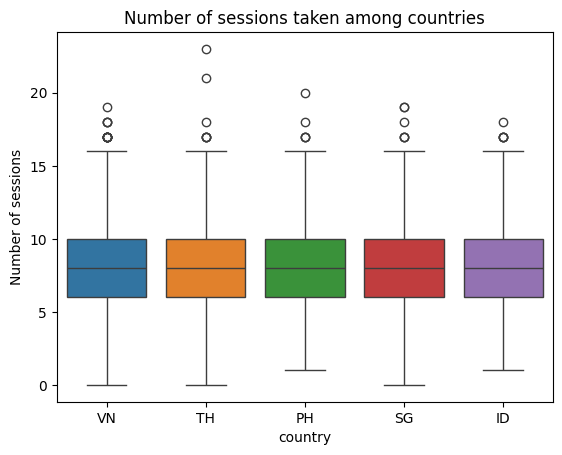

In [ ]:
# boxplots of sessions taken by country

sns.boxplot(data=df_ab_test, x='country', y='sessions', hue='country')
plt.title('Number of sessions taken among countries')
plt.ylabel('Number of sessions')
plt.show()

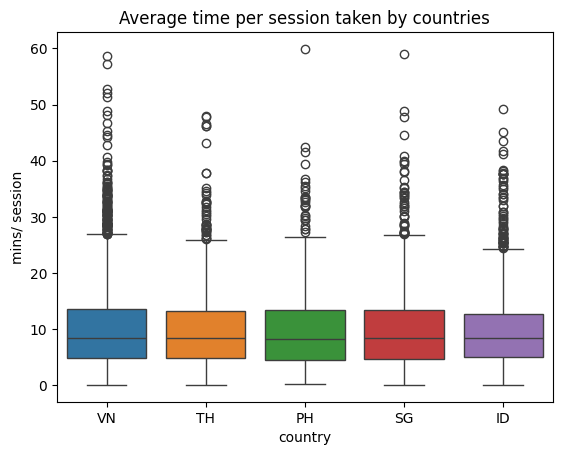

In [ ]:
# boxplots of average time per session taken by country

sns.boxplot(data=df_ab_test, x='country', y='avg_session_time_min', hue='country')
plt.title('Average time per session taken by countries')
plt.ylabel('mins/ session')
plt.show()

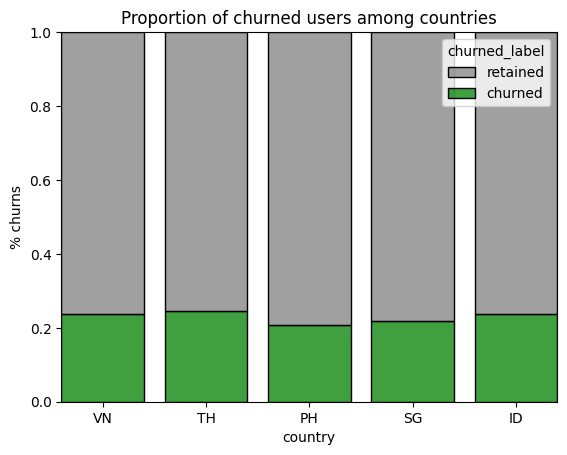

In [ ]:
# percentage of churns in different countries

ax = sns.histplot(data=df_ab_test, x='country', hue='churned_label', hue_order=['retained','churned'],
                  shrink=0.8, alpha=0.75,
                  palette={'retained':'grey', 'churned':'green'},
                 multiple='fill')
ax.set_ylabel('% churns')
ax.set_title('Proportion of churned users among countries')

sns.move_legend(ax, 'upper right')

plt.show()

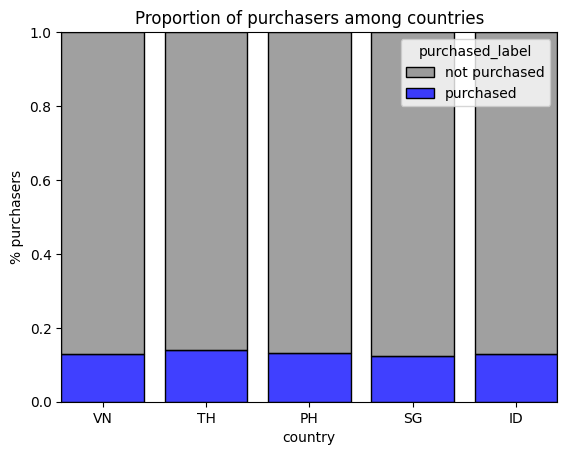

In [ ]:
# percentage of purchases in different countries

sns.histplot(data=df_ab_test, x='country', hue='purchased_label', shrink=0.8, alpha=0.75,
             palette={'not purchased':'grey', 'purchased':'blue'}, multiple='fill')
plt.ylabel('% purchasers')
plt.title('Proportion of purchasers among countries')
plt.show()

#### **Findings:**
Conversion and churn do not show an obvious pattern of differential impact across different markets in the observed sample. This suggests that there is no clear evidence of market-specific heterogeneity at the descriptive level.

### **3. Conversion rate & churn rate regarding ages**
I would like to explore on how ages affect the possibility of purchase and churn

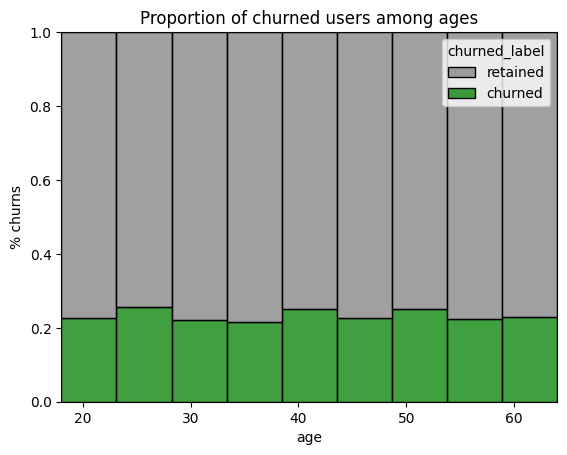

In [ ]:
# percentage of churns regarding ages

sns.histplot(data=df_ab_test, x='age', hue='churned_label', binwidth=5, alpha=0.75,
             palette={'retained':'grey', 'churned':'green'}, hue_order=['retained','churned'],
             multiple='fill')
plt.ylabel('% churns')
plt.title('Proportion of churned users among ages')
plt.show()

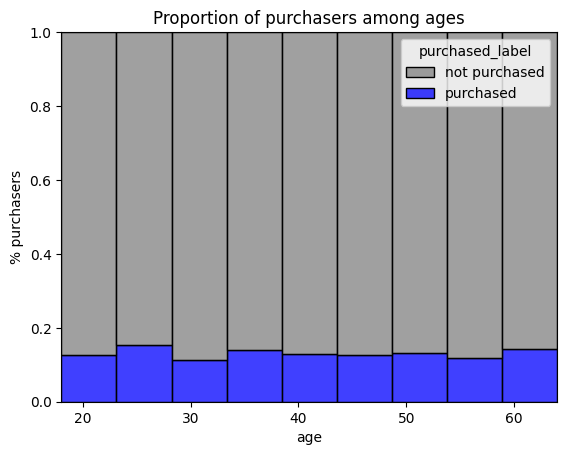

In [ ]:
# percentage of purchasers regarding ages

sns.histplot(data=df_ab_test, x='age', hue='purchased_label', binwidth=5, alpha=0.75,
             palette={'not purchased':'grey', 'purchased':'blue'}, multiple='fill')
plt.ylabel('% purchasers')
plt.title('Proportion of purchasers among ages')
plt.show()

#### **Findings:**
Conversion and churn do not show an obvious pattern of differential impact across age groups in the observed sample. This suggests that there is no clear evidence of age-specific heterogeneity at the descriptive level.

### **4. Conversion rate & churn rate of users who take excesstive session**
For `users` who stay longer in a session, I would like to explore whether they buy less or more and if the churn rate is different.<br>
I would use IQR method to isolate the outliers in `avg_session_time_min` then analyze further.

In [ ]:
# percentage of purchased and churned users in group of users taking longer sessions (outliers in avg_session_time_min)

quartile_1, quartile_3 = np.quantile(df_ab_test.avg_session_time_min, [0.25, 0.75])
iqr = quartile_3 - quartile_1
lower_bound = quartile_1 - (1.5 * iqr)
upper_bound = quartile_3 + (1.5 * iqr)

df_ab_test_outlier = df_ab_test[(df_ab_test.avg_session_time_min < lower_bound) | (df_ab_test.avg_session_time_min > upper_bound)]

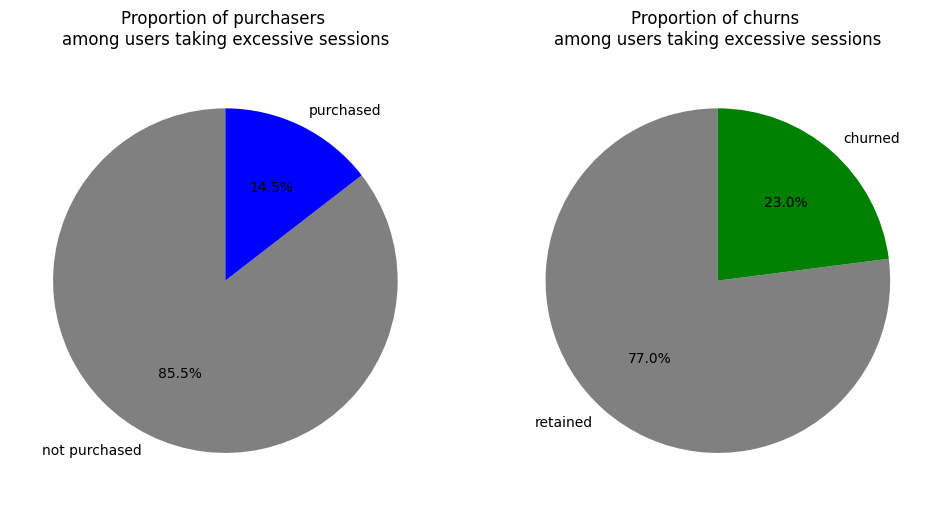

In [ ]:
from matplotlib import colors
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

ax[0].pie(df_ab_test_outlier.converted.value_counts(),
          labels= ['not purchased', 'purchased'],
          autopct='%1.1f%%',
          colors= ['grey','blue'],
          startangle=90)
ax[0].set_title('Proportion of purchasers \namong users taking excessive sessions',
                pad=15)

ax[1].pie(df_ab_test_outlier.churned.value_counts(),
          labels= ['retained', 'churned'],
          autopct='%1.1f%%',
          colors=['grey', 'green'],
          startangle=90)
ax[1].set_title('Proportion of churns \namong users taking excessive sessions',
                pad=15)

plt.tight_layout()
plt.show()

> 14.5% excessive users have purchased and 23% of them churned, approximately equal to the total (~13% and ~23% relatively)

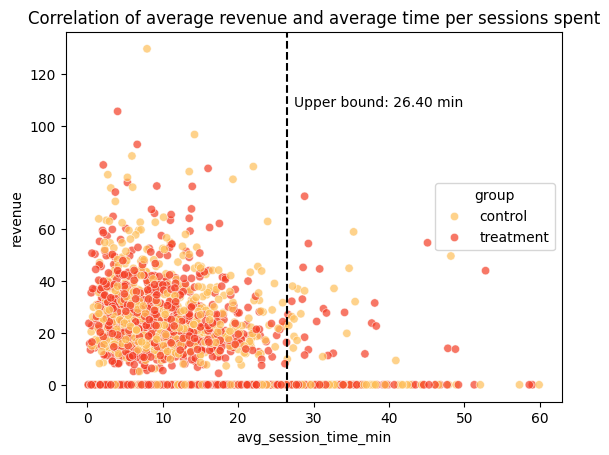

In [ ]:
# correlation between average time per session and average revenue spent

sns.scatterplot(data=df_ab_test, x='avg_session_time_min', y='revenue', hue='group',
                palette='YlOrRd', markers=True, alpha=0.7)

plt.axvline(x=upper_bound, color='black', linestyle='--')
plt.text(upper_bound + 1, plt.ylim()[1] * 0.8,
         f'Upper bound: {upper_bound:.2f} min',
         color='black', ha='left', va='center',
         bbox=dict(boxstyle='round,pad=0.3',
                   fc='white', ec='none',
                   alpha=0.7))

plt.title('Correlation of average revenue and average time per sessions spent')
plt.show()

> Interestingly, highest revenue users fall into the range below to the upper bound.


#### **Findings:**
1. Users with longer session durations do not appear to show a materially different conversion or churn pattern from users with more typical session durations in the observed sample.
2. Longer session duration is not associated with higher order value in the observed sample. This may reflect user hesitation, lower purchase intent, or other post-treatment dynamics (but the analysis does not support a causal interpretation).<br>
**This pattern may motivate a future hypothesis that session duration is related to purchase quality.**

### **5. Correlation between converted status and churned status**
I would like to explore further on if `churned buyers` and `retained buyers` have difference in purchase behaviors.<br> Whether it has a correlation between buying attributes and churned users.

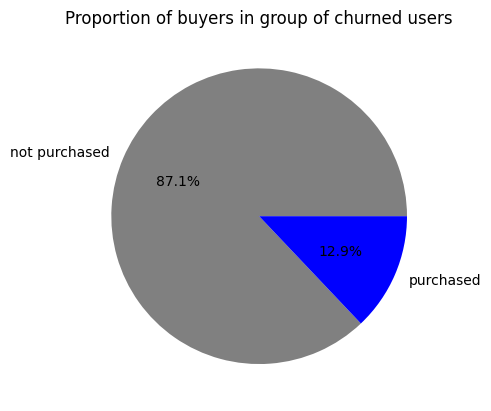

In [ ]:
# percentage of buyers in group of users who churned

churned = df_ab_test[df_ab_test['churned'] == 1]

plt.pie(churned['purchased_label'].value_counts(),
        labels= churned['purchased_label'].value_counts().index,
        autopct='%1.1f%%',
        colors=['grey', 'blue'])
plt.title('Proportion of buyers in group of churned users')
plt.show()

> 12.9% churned users have placed orders which is approximate to the total (~13% total users have placed orders).

In [ ]:
# the median of 'sessions', 'avg_session_time_min','avg_revenue_per_session' of `buyers` by `churn status`

df_ab_test[df_ab_test['converted']==1].groupby('churned_label')[['sessions','avg_session_time_min','revenue']].agg(['mean','median'])

sessions        avg_session_time_min           revenue       
                   mean median                 mean median       mean median
churned_label                                                               
churned        7.551495    7.0            10.133555    8.9  26.842791  22.96
retained       8.235119    8.0             9.983333    8.2  27.230823  24.52

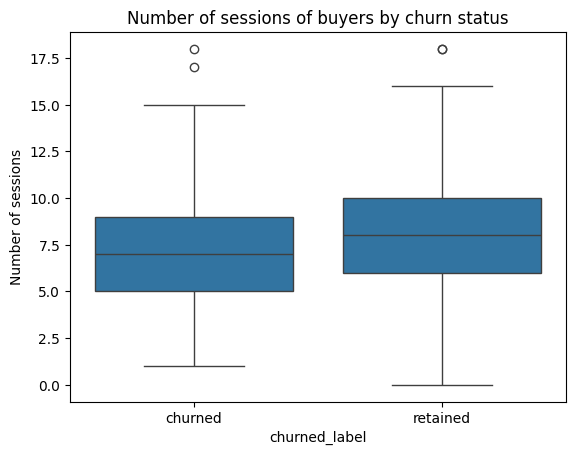

In [ ]:
# comparison of 'sessions' of buyers by `churn status`

sns.boxplot(data=df_ab_test[df_ab_test['converted']==1], x='churned_label', y='sessions')
plt.title('Number of sessions of buyers by churn status')
plt.ylabel('Number of sessions')
plt.show()

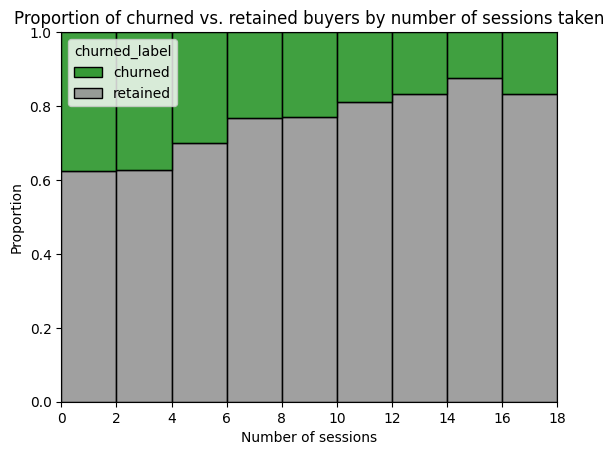

In [ ]:
# proportion of churn status in `buyers` by total sessions taken

sns.histplot(data=df_ab_test[df_ab_test['converted'] == 1], x='sessions', binwidth=2, hue='churned_label', alpha=0.75,
             palette={'retained': 'grey', 'churned': 'green'}, multiple='fill')
plt.title('Proportion of churned vs. retained buyers by number of sessions taken')
plt.ylabel('Proportion')
plt.xlabel('Number of sessions')
plt.show()

> 30% - 40% `buyers` churned taking below 6 sessions and it reduces gradually afterwards. Understandingly, they could not take more sessions once churned.

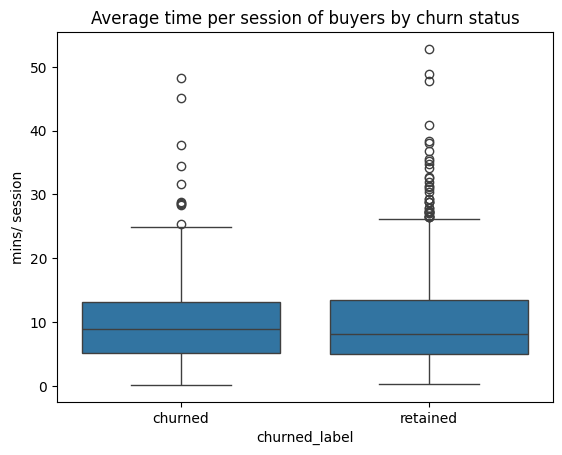

In [ ]:
# boxplot of 'avg_session_time_min' of `buyers` by `churn status`

sns.boxplot(data=df_ab_test[df_ab_test['converted']==1], x='churned_label', y='avg_session_time_min')
plt.title('Average time per session of buyers by churn status')
plt.ylabel('mins/ session')
plt.show()

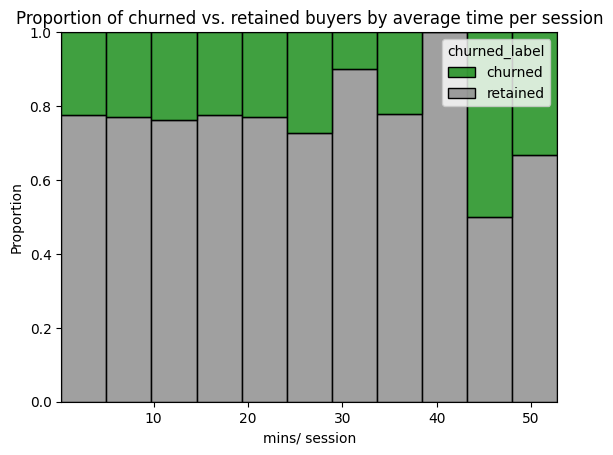

In [ ]:
# proportion of churn status of `buyers` by average time per session taken

sns.histplot(data=df_ab_test[df_ab_test['converted'] == 1], x='avg_session_time_min', binwidth=5, hue='churned_label', alpha=0.75,
             palette={'retained': 'grey', 'churned': 'green'}, multiple='fill')
plt.title('Proportion of churned vs. retained buyers by average time per session')
plt.ylabel('Proportion')
plt.xlabel('mins/ session')
plt.show()

> `Buyers` spending more than 40 minutes/ session are churned more than the remaining.

In [ ]:
df = df_ab_test[(df_ab_test['converted']==1) & (df_ab_test['avg_session_time_min'] > 40)]

df.groupby('churned_label')[['sessions','revenue']].agg(['mean','median'])

sessions        revenue        
                  mean median    mean  median
churned_label                                
churned            6.5    6.5  52.310  52.310
retained          10.5   10.5  20.335  13.935

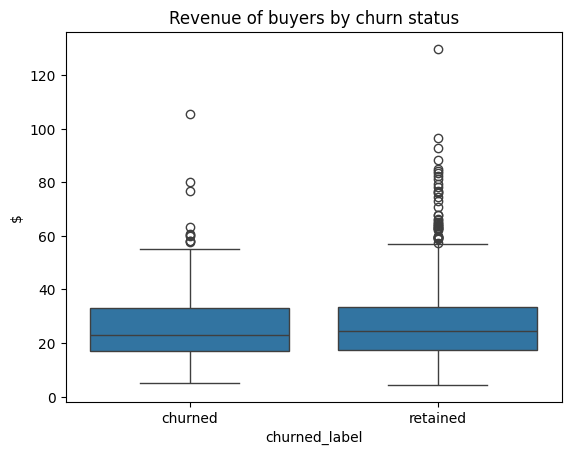

In [ ]:
# boxplot of 'revenue' of `buyers` by `churn status`

sns.boxplot(data=df_ab_test[df_ab_test['converted']==1], x='churned_label', y='revenue')
plt.title('Revenue of buyers by churn status')
plt.ylabel('$')
plt.show()

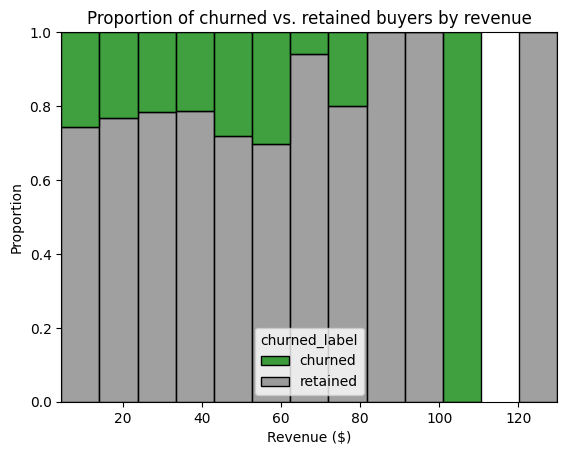

In [ ]:
# proportion of churn status of `buyers` by revenue

sns.histplot(data=df_ab_test[df_ab_test['converted'] == 1], x='revenue', hue='churned_label', binwidth=10, alpha=0.75,
             palette={'retained': 'grey', 'churned': 'green'}, multiple='fill')
plt.title('Proportion of churned vs. retained buyers by revenue')
plt.ylabel('Proportion')
plt.xlabel('Revenue ($)')
plt.show()

#### **Findings:**
1. In perspective of shopping behaviours, the difference between `retained buyers` and `churned buyers` is subtle.<br> This finding suggests that the root cause of churn decisions needs analyzing with augmenting data. A reasonable hypothesis is buyers churned after they had received their packages due to products or service quality.
2. We also notice that `buyers spend > 40 mins/ session` seemingly churn at a higher rate (~40%) than those who spend shorter time. Previously, we have known that the longer session, the less probability users place high amount orders. <br>Those patterns altogether might suggest some frictions that users must take longer time to reach the final step.